# Cloning the Repo

In [1]:
#!git clone https://github.com/Tahoni01/Continual-hate-speech-detection.git
%cd Continual-hate-speech-detection

[WinError 2] Impossibile trovare il file specificato: 'Continual-hate-speech-detection'
c:\Uni\Continual-hate-speech-detection


# Install all the necessary library

In [2]:
%pip install -r requirements.txt

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## ⚙️ Imports & configuration

Loads all project modules and sets global constants. `DEVICE` auto-selects GPU if available.

`BATCH_SIZE=64` and `EVAL_EVERY=75` were chosen after empirical testing, smaller batches
increase ADWIN noise, larger eval intervals reduce training overhead without losing curve granularity.

In [3]:
# ─── CELL 1 — imports ────────────────────────────────────────────────────────
import os
import torch
from transformers import AutoTokenizer

from dataset.df_loader   import LABEL_MAP, load_davidson, load_hatexplain, get_class_weights
from dataset.stream_generator import create_stream, create_continual_stream, stream_info
from model_utils.model_builder         import HateSpeechClassifier
from model_utils.trainer             import ContinualTrainer
from model_utils.tuner import ContinualTuner
from strategy.replay     import ReplayStrategy
from strategy.ewc        import EWCStrategy
from strategy.derpp       import DERppStrategy
from utils.metrics       import compute_accuracy, compute_f1, compute_all
from utils.plot_utils    import (
    plot_label_distribution, plot_stream_shift,
    plot_loss, plot_eval_log, plot_conf_matrix,
    plot_comparison, plot_eval_logs_comparison,
    plot_per_class_f1
)

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
EVAL_EVERY = 75
print(f"Device: {DEVICE} | GPU: {torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'N/A'}")

Device: cuda | GPU: NVIDIA GeForce RTX 5070 Laptop GPU


## 📂 Dataset loading

Loads Davidson (HuggingFace) and HateXplain (GitHub JSON) and builds the continual stream.
The two datasets are concatenated in order with no inter-dataset shuffle, this is intentional.
The abrupt shift at the boundary is what makes this a meaningful CL scenario.

Davidson: ~19,000 tweets, 78% offensive.
HateXplain: ~15,000 posts, roughly balanced across the three classes.

In [4]:
train_dv, val_dv = load_davidson()
train_hx, val_hx = load_hatexplain()

class_weights = get_class_weights(train_dv, train_hx)

stream        = create_continual_stream(train_dv, train_hx, batch_size=BATCH_SIZE)
val_stream_dv = create_stream(val_dv, batch_size=BATCH_SIZE)
val_stream_hx = create_stream(val_hx, batch_size=BATCH_SIZE)
VAL_STREAMS   = {"davidson": val_stream_dv, "hatexplain": val_stream_hx}
BOUNDARY      = len(create_stream(train_dv, batch_size=BATCH_SIZE))

stream_info(stream, "full stream")

Davidson   — train: 19448 | val: 4862
HateXplain — train: 16115 | val: 4029
  hatespeech  : 1.800
  offensive   : 0.609
  normal      : 1.247
full stream: 1112 batches | 35563 samples | {'davidson': 19448, 'hatexplain': 16115}


## 📊 Dataset analysis

Visual inspection of the two datasets before training. The label distribution plot shows
the prior shift clearly, Davidson is dominated by "offensive" while HateXplain is balanced.
The stream shift plot shows how class ratios change abruptly at the dataset boundary.
This shift is what the anti-forgetting strategies are designed to handle.

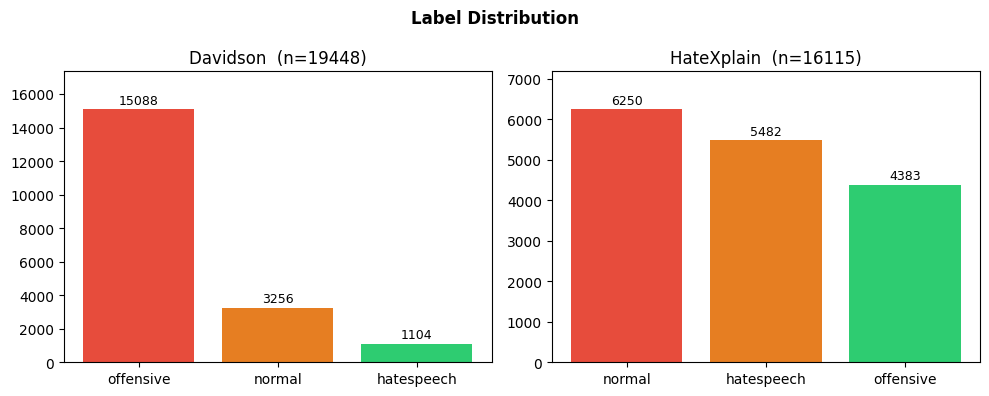

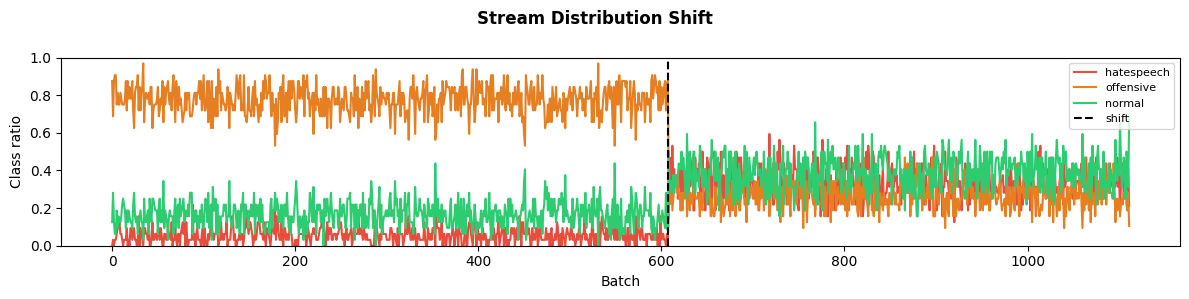

In [5]:
plot_label_distribution(train_dv, train_hx, names=["Davidson", "HateXplain"])
plot_stream_shift(stream)

## 🧪 Experiment setup

Defines the four strategies as factory lambdas, each call produces a fresh instance with
clean state, preventing any contamination between runs. `_run_experiment` handles the full
pipeline: model instantiation, training, evaluation, model saving, and result collection.
The tuner is attached automatically for strategies that have tunable hyperparameters (EWC, DER++).

In [ ]:
os.makedirs("models", exist_ok=True)
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilroberta-base")

EXPERIMENTS = {
    "Baseline":   lambda: [],
    "Replay":     lambda: [ReplayStrategy(buffer_size=1000)],
    "Replay+EWC": lambda: [ReplayStrategy(buffer_size=1000), EWCStrategy()],
    "DER++":      lambda: [DERppStrategy()],
}

cl_results = {}

def _run_experiment(name, strategy_factory):
    print(f"\n{'='*50}\nExperiment: {name}\n{'='*50}")

    model     = HateSpeechClassifier(num_labels=3)
    trainer   = ContinualTrainer(model, tokenizer, device=DEVICE, lr=2e-5, adwin_delta=0.002, lr_decay=0.5)
    strategies = strategy_factory()

    for s in strategies:
        trainer.add_strategy(s)

    if strategies:
        trainer.set_tuner(ContinualTuner(strategies))

    result = trainer.train(stream, LABEL_MAP, VAL_STREAMS, eval_every=EVAL_EVERY)
    losses = result["task"]

    preds_dv, labels_dv = trainer.evaluate(val_stream_dv, LABEL_MAP)
    preds_hx, labels_hx = trainer.evaluate(val_stream_hx, LABEL_MAP)
    metrics = compute_all(trainer.eval_log, "davidson", "hatexplain",
                          boundary_batch=BOUNDARY)

    print(f"Davidson   — Acc={compute_accuracy(preds_dv,labels_dv):.4f} | F1={compute_f1(preds_dv,labels_dv):.4f}")
    print(f"HateXplain — Acc={compute_accuracy(preds_hx,labels_hx):.4f} | F1={compute_f1(preds_hx,labels_hx):.4f}")
    print(f"Drift at batch: {trainer.drift_batch}")

    cl_results[name] = {
        "losses":   losses,          # ← task loss
        "eval_log": trainer.eval_log,
        "metrics":  metrics,
        "drift_at": trainer.drift_batch,
        "preds_dv": preds_dv, "labels_dv": labels_dv,
        "preds_hx": preds_hx, "labels_hx": labels_hx,
    }

    safe_name = name.replace("+", "_").replace(" ", "_")
    trainer.save(f"models/{safe_name}.pt")
    print(f"Model saved → models/{safe_name}.pt")
    

## 📉 Baseline

No anti-forgetting strategy. The model trains normally on the full stream without any
mechanism to protect knowledge from Davidson. This is the worst-case reference point
all improvements from the other strategies are measured relative to this.


Experiment: Baseline


Training:  61%|██████    | 675/1112 [02:14<00:12, 35.09it/s]


[ADWIN] Drift detected at batch 671
[ADWIN] LR decayed by 0.5x


Training: 100%|██████████| 1112/1112 [03:47<00:00,  4.89it/s]


BWT  (davidson): -0.4198  (forgetting)
FWT  (hatexplain):  0.4413  (zero-shot before training)
AAA  (all tasks):  0.6292  (avg anytime accuracy)
Davidson   — Acc=0.4868 | F1=0.4383
HateXplain — Acc=0.6513 | F1=0.5903
Drift at batch: 671
Model saved → models/Baseline.pt


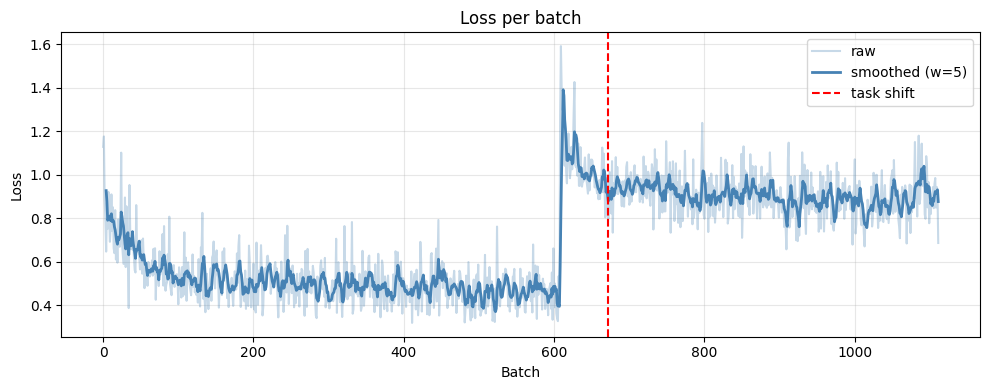

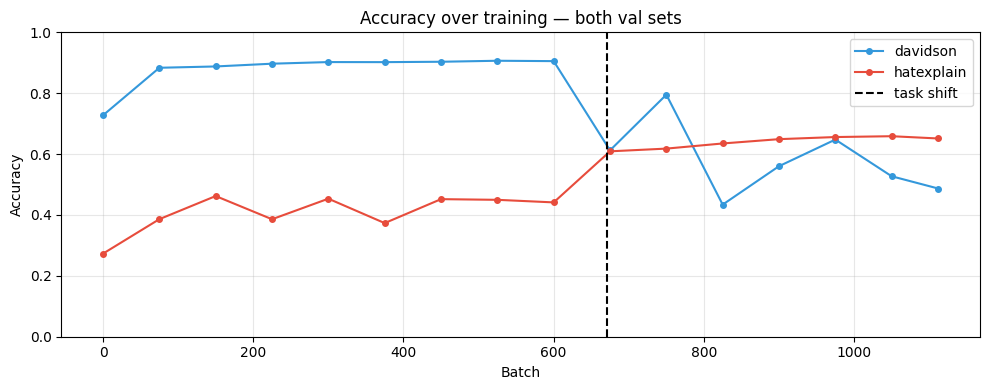

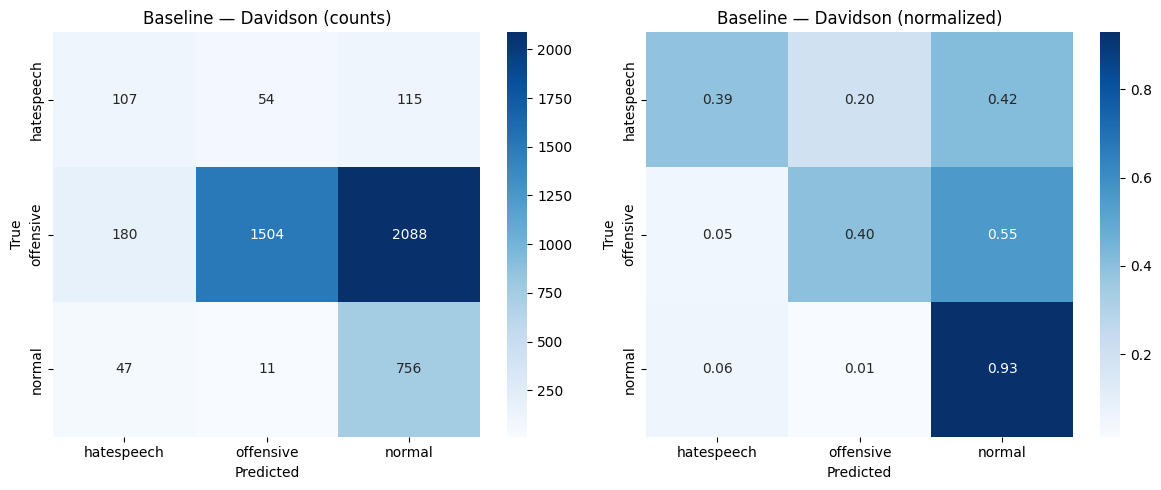

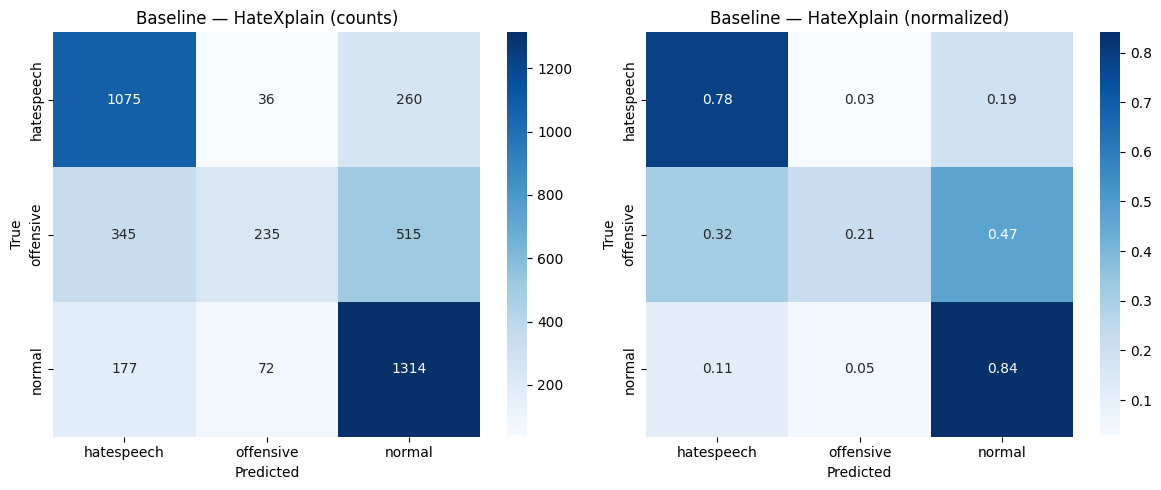

In [7]:
_run_experiment("Baseline", EXPERIMENTS["Baseline"])

res = cl_results["Baseline"]
plot_loss(res["losses"], boundary=res["drift_at"])
plot_eval_log(res["eval_log"], boundary=res["drift_at"])
plot_conf_matrix(res["preds_dv"], res["labels_dv"], LABEL_MAP, title="Baseline — Davidson")
plot_conf_matrix(res["preds_hx"], res["labels_hx"], LABEL_MAP, title="Baseline — HateXplain")

## 🔁 Replay

Class-balanced reservoir replay. One buffer is maintained per class, each of fixed capacity:

$$\text{slot\_size} = \left\lfloor \frac{\text{buffer\_size}}{\text{n\_classes}} \right\rfloor$$

This guarantees equal class representation in the replay buffer regardless of how skewed
the stream is — Davidson is 78% offensive, which would otherwise dominate a standard reservoir.

The buffer fills silently during Davidson and activates only after ADWIN detects the
distribution shift. Replaying Davidson samples while still training on Davidson would
be redundant and add unnecessary noise to the gradients.


Experiment: Replay


Training:  60%|██████    | 671/1112 [02:15<00:13, 33.14it/s]


[ADWIN] Drift detected at batch 671
[ADWIN] LR decayed by 0.5x

[Tuner] HP search on 137 old + 63 new batches


Training:  61%|██████    | 675/1112 [02:21<03:30,  2.07it/s]

[Tuner] Plasticity ceiling A = 0.6731


Training: 100%|██████████| 1112/1112 [03:55<00:00,  4.73it/s]


BWT  (davidson): -0.1382  (forgetting)
FWT  (hatexplain):  0.4378  (zero-shot before training)
AAA  (all tasks):  0.6514  (avg anytime accuracy)
Davidson   — Acc=0.7686 | F1=0.5988
HateXplain — Acc=0.6592 | F1=0.6294
Drift at batch: 671
Model saved → models/Replay.pt


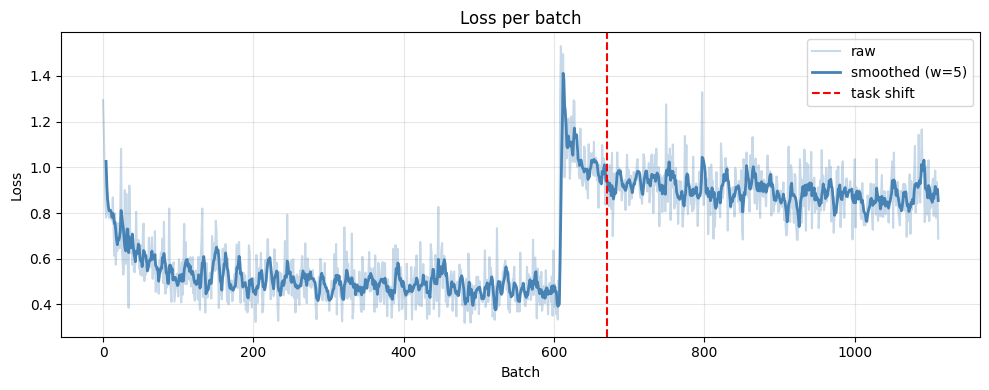

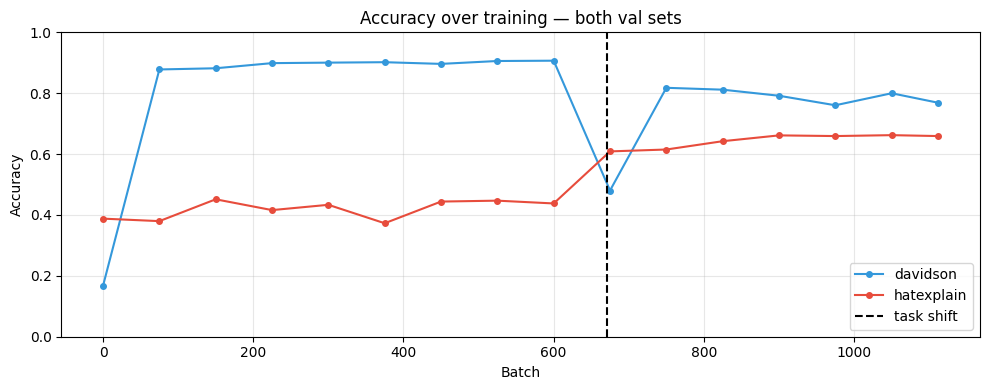

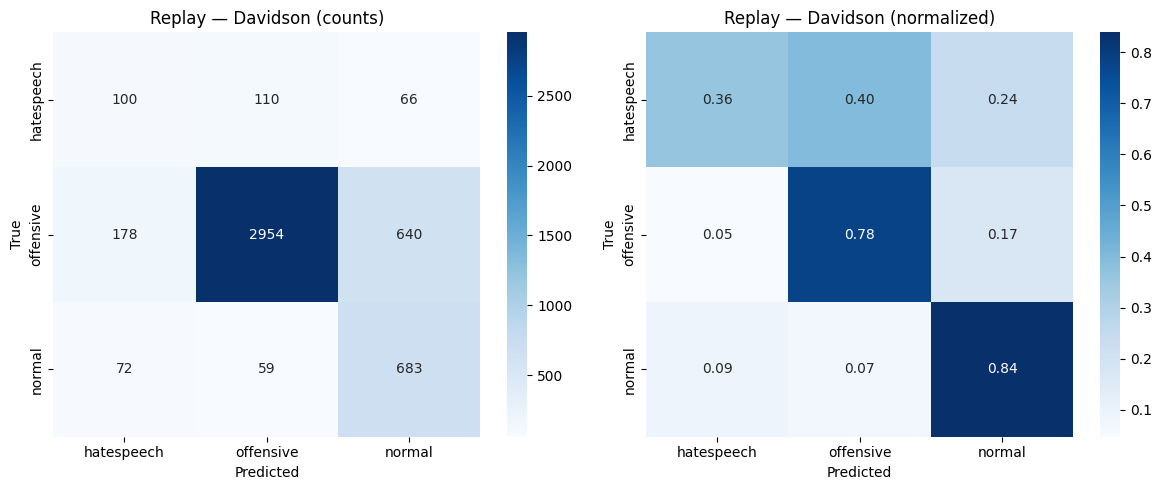

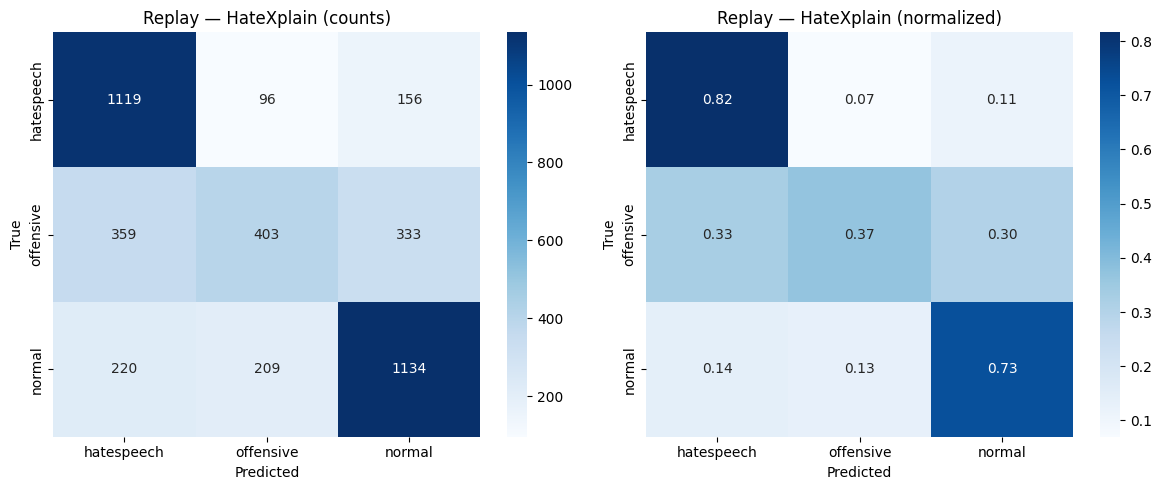

In [8]:
_run_experiment("Replay", EXPERIMENTS["Replay"])

res = cl_results["Replay"]
plot_loss(res["losses"], boundary=res["drift_at"])
plot_eval_log(res["eval_log"], boundary=res["drift_at"])
plot_conf_matrix(res["preds_dv"], res["labels_dv"], LABEL_MAP, title="Replay — Davidson")
plot_conf_matrix(res["preds_hx"], res["labels_hx"], LABEL_MAP, title="Replay — HateXplain")

## 🔁🔒 Replay + EWC

Combines replay with Elastic Weight Consolidation. The two methods act on different dimensions:
replay acts on the data (brings Davidson samples into HateXplain training), while EWC acts on
the parameters (penalizes deviation from weights that were important for Davidson).
Fisher information is computed on the recent buffer at drift detection using the Practical Fisher estimator.


Experiment: Replay+EWC


Training:  60%|██████    | 671/1112 [02:21<00:22, 19.61it/s]


[ADWIN] Drift detected at batch 671
[ADWIN] LR decayed by 0.5x

[Tuner] HP search on 137 old + 63 new batches
[Tuner] Plasticity ceiling A = 0.6761
[Tuner] Searching EWCStrategy over 3 configs...


Training:  60%|██████    | 671/1112 [02:35<00:22, 19.61it/s]

  {'lambda_': 0.01} → A*=0.6756 forgetting=0.1828 ✓
  {'lambda_': 0.1} → A*=0.6706 forgetting=0.1543 ✓
  {'lambda_': 1.0} → A*=0.6756 forgetting=0.3901 ✓
[Tuner] Best: {'lambda_': 0.1} (forgetting=0.1543)


Training:  61%|██████    | 674/1112 [03:53<1:09:26,  9.51s/it]

[EWC] Fisher computed on 200 batches (lambda=0.1)


Training: 100%|██████████| 1112/1112 [05:47<00:00,  3.20it/s] 


BWT  (davidson): -0.1974  (forgetting)
FWT  (hatexplain):  0.4150  (zero-shot before training)
AAA  (all tasks):  0.6461  (avg anytime accuracy)
Davidson   — Acc=0.7104 | F1=0.5608
HateXplain — Acc=0.6664 | F1=0.6407
Drift at batch: 671
Model saved → models/Replay_EWC.pt


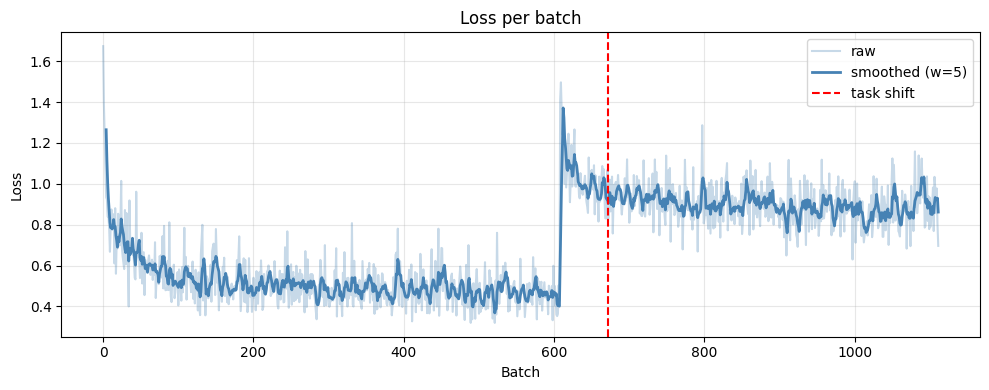

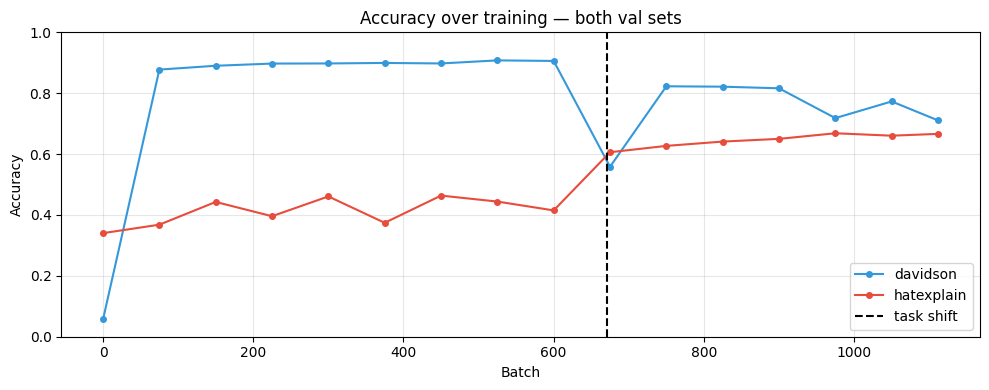

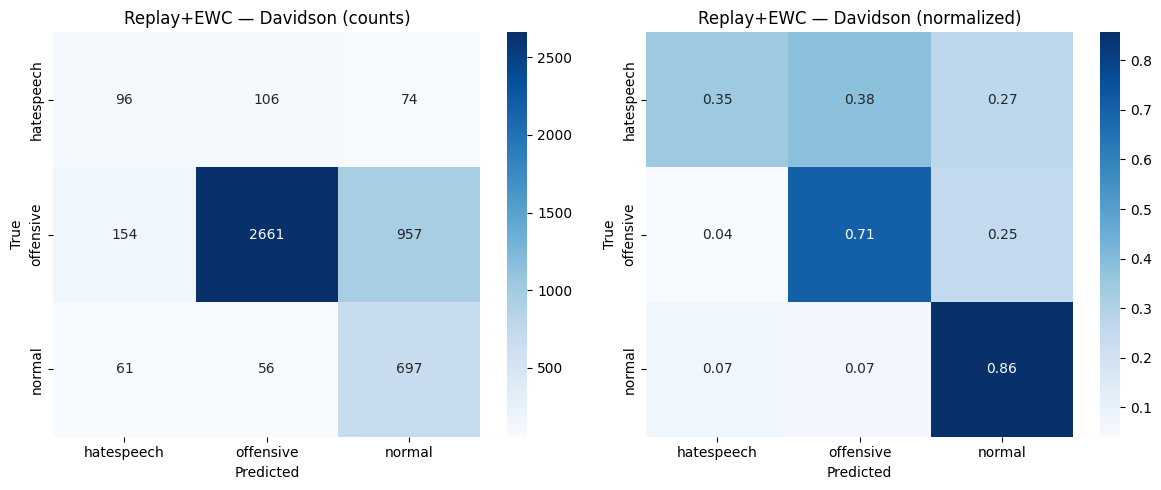

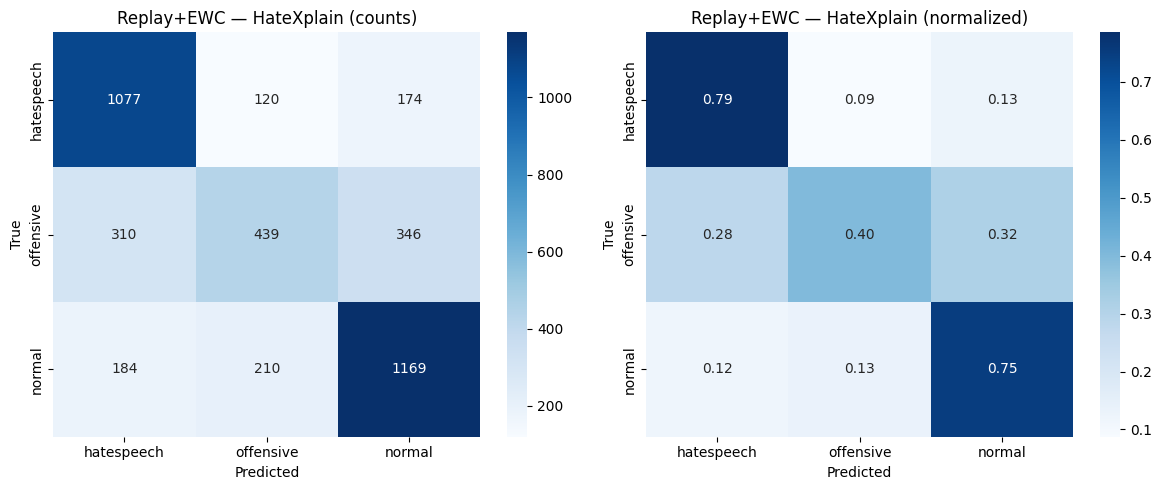

In [9]:
_run_experiment("Replay+EWC", EXPERIMENTS["Replay+EWC"])

res = cl_results["Replay+EWC"]
plot_loss(res["losses"], boundary=res["drift_at"])
plot_eval_log(res["eval_log"], boundary=res["drift_at"])
plot_conf_matrix(res["preds_dv"], res["labels_dv"], LABEL_MAP, title="Replay+EWC — Davidson")
plot_conf_matrix(res["preds_hx"], res["labels_hx"], LABEL_MAP, title="Replay+EWC — HateXplain")

## ⚡ DER++

#### Dark Experience Replay++ (Buzzega et al., 2020). 

Extends replay by storing the model's output
logits at insertion time alongside the labels. At replay time, an MSE loss penalizes the model
for producing outputs that differ from those stored logits, a form of functional regularization
that preserves the model's past behavior, not just its parameter values.
The alpha/beta tradeoff between MSE and CE is tuned automatically by the continual tuner at drift.


Experiment: DER++


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 5d931a70-aebe-4b73-af95-b1e43c6b528d)')' thrown while requesting HEAD https://huggingface.co/distilbert/distilroberta-base/resolve/main/config.json
Retrying in 1s [Retry 1/5].
Training:  60%|██████    | 668/1112 [02:08<00:13, 32.66it/s]


[ADWIN] Drift detected at batch 671
[ADWIN] LR decayed by 0.5x

[Tuner] HP search on 137 old + 63 new batches
[Tuner] Plasticity ceiling A = 0.6801
[Tuner] Searching DERppStrategy over 3 configs...


Training:  60%|██████    | 668/1112 [02:19<00:13, 32.66it/s]

  {'alpha': 0.1, 'beta': 1.0} → A*=0.6647 forgetting=0.3110 ✓
  {'alpha': 0.3, 'beta': 1.0} → A*=0.6706 forgetting=0.1673 ✓


Training:  61%|██████    | 674/1112 [03:35<39:21,  5.39s/it]

  {'alpha': 0.5, 'beta': 1.0} → A*=0.6657 forgetting=0.1321 ✓
[Tuner] Best: {'alpha': 0.5, 'beta': 1.0} (forgetting=0.1321)


Training: 100%|██████████| 1112/1112 [05:16<00:00,  3.52it/s]


BWT  (davidson): -0.1748  (forgetting)
FWT  (hatexplain):  0.4083  (zero-shot before training)
AAA  (all tasks):  0.6561  (avg anytime accuracy)
Davidson   — Acc=0.7314 | F1=0.5685
HateXplain — Acc=0.6570 | F1=0.6273
Drift at batch: 671
Model saved → models/DER__.pt


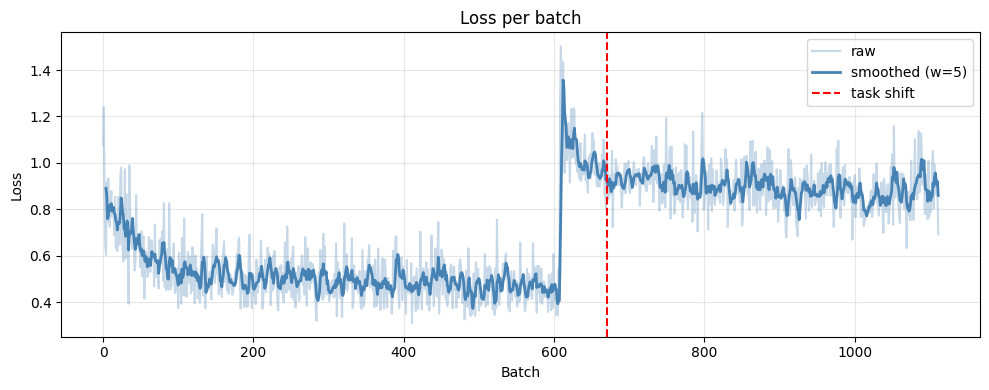

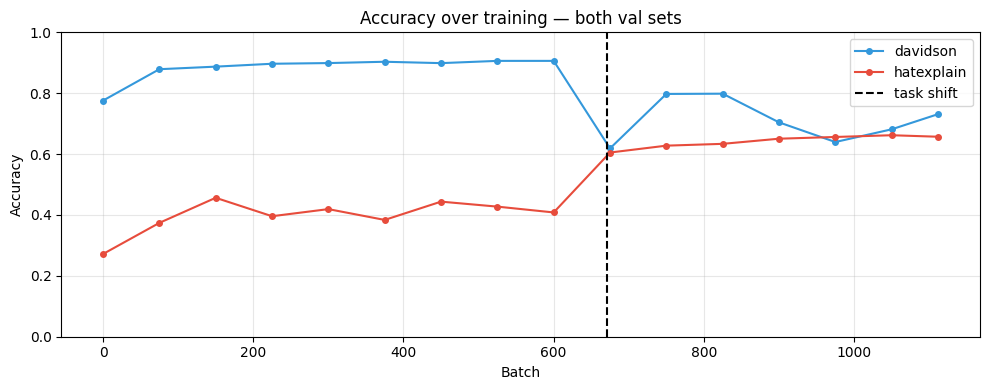

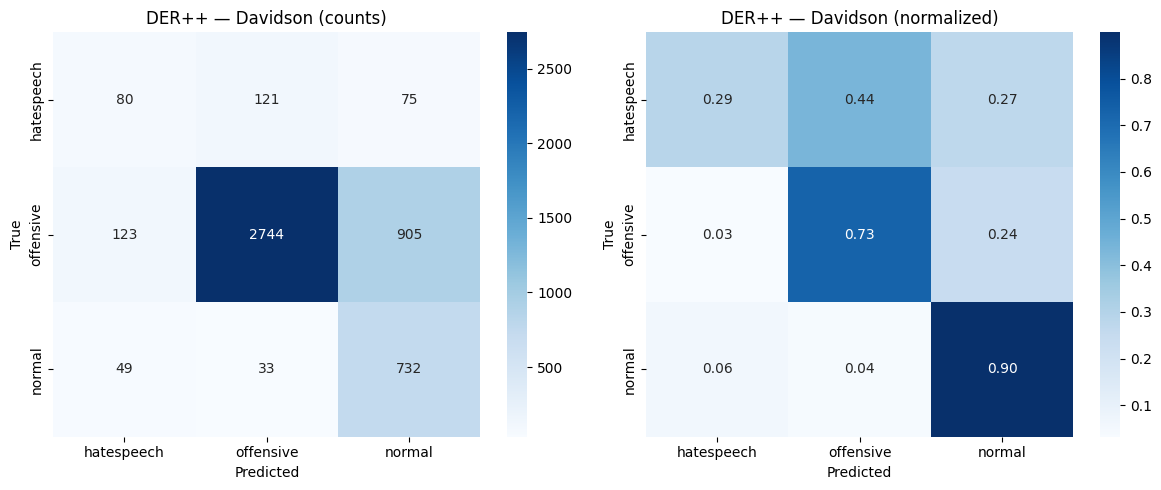

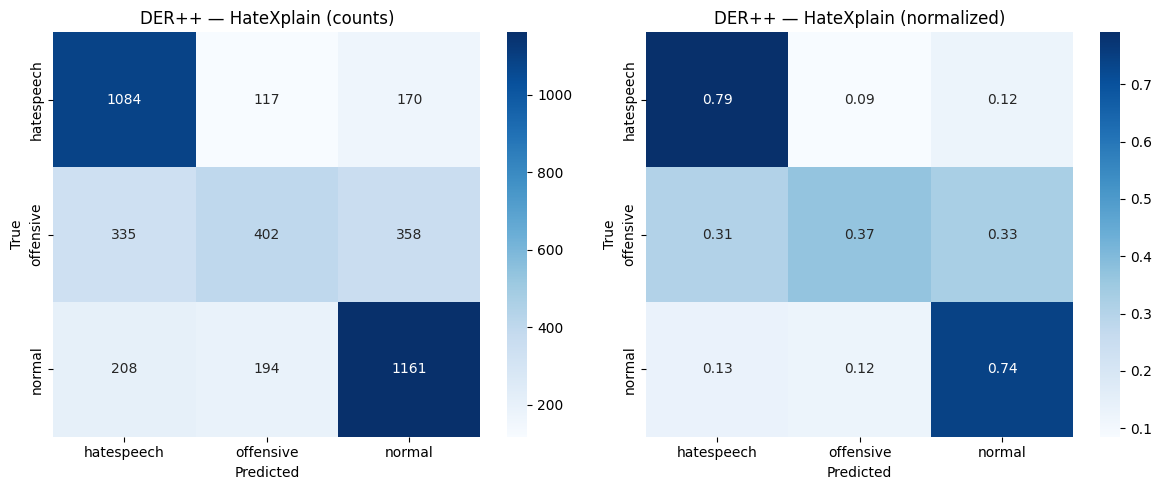

In [10]:
_run_experiment("DER++", EXPERIMENTS["DER++"])

res = cl_results["DER++"]
plot_loss(res["losses"], boundary=res["drift_at"])
plot_eval_log(res["eval_log"], boundary=res["drift_at"])
plot_conf_matrix(res["preds_dv"], res["labels_dv"], LABEL_MAP, title="DER++ — Davidson")
plot_conf_matrix(res["preds_hx"], res["labels_hx"], LABEL_MAP, title="DER++ — HateXplain")

## 📈 Final comparison

Aggregates results across all experiments and computes the standard CL metrics:
- **BWT** (Backward Transfer): how much Davidson performance dropped after HateXplain training
- **FWT** (Forward Transfer): zero-shot performance on HateXplain before seeing any of its data
- **AAA** (Average Anytime Accuracy): mean accuracy across both tasks at every logged checkpoint

Results are displayed as a table and saved to `results.csv`.

c:\Uni\Continual-hate-speech-detection\utils\plot_utils.py:197: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
c:\Uni\Continual-hate-speech-detection\utils\plot_utils.py:197: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
c:\Uni\Continual-hate-speech-detection\utils\plot_utils.py:197: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
c:\Uni\Continual-hate-speech-detection\utils\plot_utils.py:197: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=

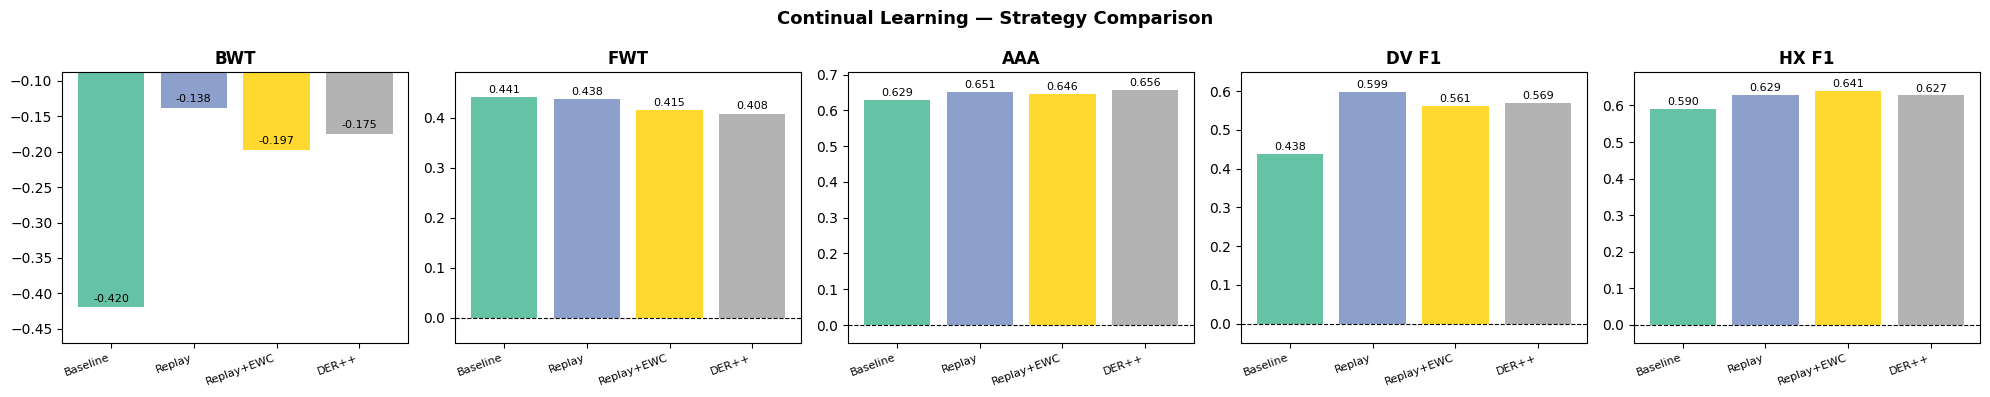

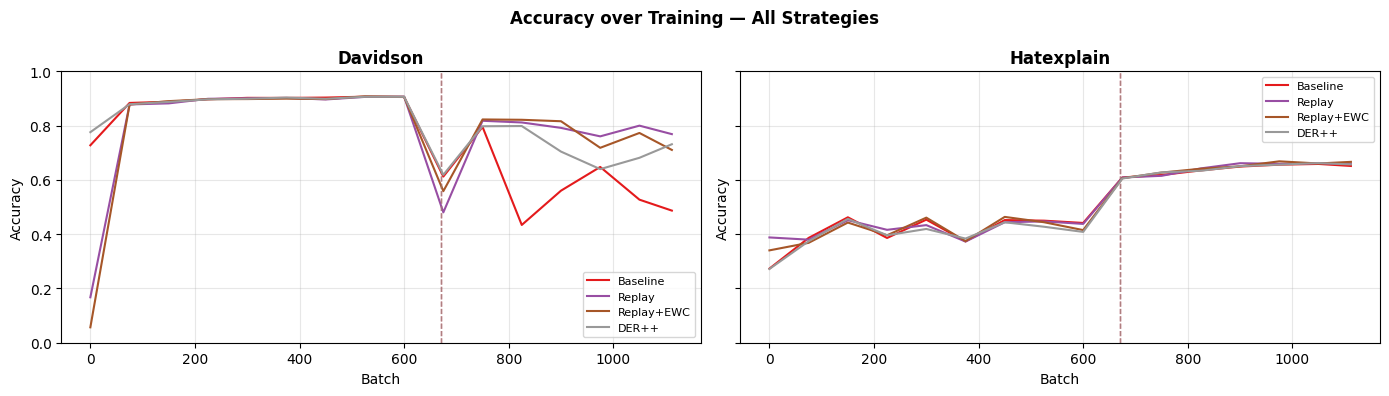

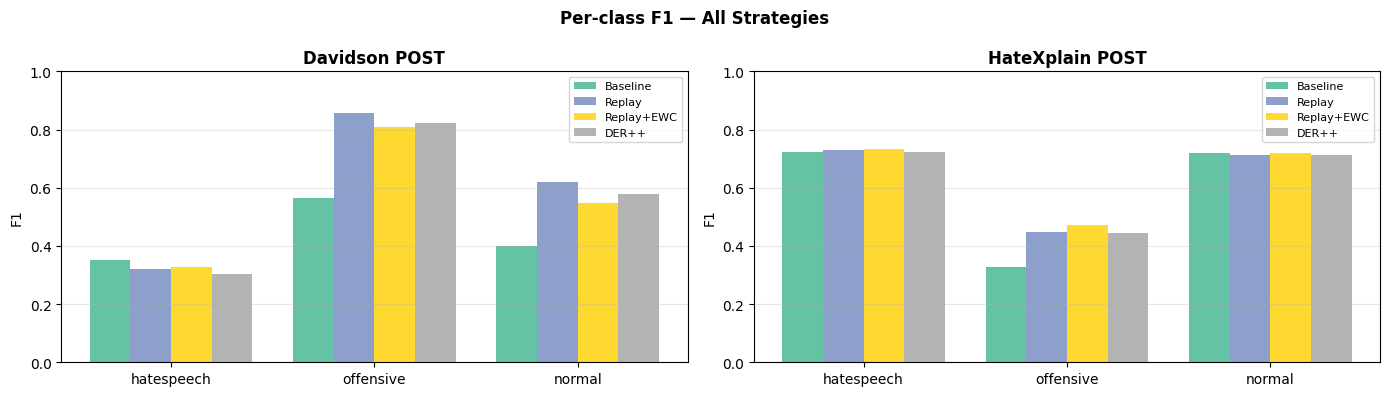

,BWT,Forgetting,FWT,AAA,DV Acc,DV F1,HX Acc,HX F1,Drift batch
Experiment,,,,,,,,,
Baseline,-0.4198,0.4198,0.4413,0.6292,0.4868,0.4383,0.6513,0.5903,671
Replay,-0.1382,0.1382,0.4378,0.6514,0.7686,0.5988,0.6592,0.6294,671
Replay+EWC,-0.1974,0.1974,0.4150,0.6461,0.7104,0.5608,0.6664,0.6407,671
DER++,-0.1748,0.1748,0.4083,0.6561,0.7314,0.5685,0.6570,0.6273,671


Saved → results.csv


In [11]:
import pandas as pd
from utils.metrics import compute_accuracy, compute_f1

plot_comparison(cl_results, LABEL_MAP)
plot_eval_logs_comparison(cl_results)
plot_per_class_f1(cl_results, LABEL_MAP)

rows = []
for name, res in cl_results.items():
    m = res["metrics"]
    rows.append({
        "Experiment":  name,
        "BWT":         round(m["bwt"], 4),
        "Forgetting":  round(-m["bwt"], 4),
        "FWT":         round(m["fwt"], 4),
        "AAA":         round(m["aaa"], 4),
        "DV Acc":      round(compute_accuracy(res["preds_dv"], res["labels_dv"]), 4),
        "DV F1":       round(compute_f1(res["preds_dv"], res["labels_dv"]), 4),
        "HX Acc":      round(compute_accuracy(res["preds_hx"], res["labels_hx"]), 4),
        "HX F1":       round(compute_f1(res["preds_hx"], res["labels_hx"]), 4),
        "Drift batch": res["drift_at"],
    })

df_results = pd.DataFrame(rows).set_index("Experiment")
display(df_results)
df_results.to_csv("results.csv")
print("Saved → results.csv")